In [1]:
from google.colab import files
import pandas as pd

# Upload heards dataset
uploaded = files.upload()

# Load into DataFrame
heards_df = pd.read_csv("heards_structured_cleaned_v11.csv")

# Quick sanity check
print(heards_df.shape)
heards_df.head()


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv
(154903, 12)


,updatedDate,start_date,end_date,action_type,party,price,price_basis,location,volume_min,volume_max,headline,duration_days
0,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
1,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
2,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
3,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,328.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
4,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4


In [2]:
# Upload MOPS380 dataset
uploaded = files.upload()

# Open raw to inspect first few lines
with open("CI_SymbolPrice_2025-06-02T030407Z.csv", "r") as f:
    for _ in range(10):  # print first 10 lines
        print(f.readline())

# Load, skipping metadata rows until actual data starts
# (typically metadata takes up ~2-3 rows, adjust skiprows after inspecting above)



Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv
Description,FO 380 CST 3.5%S FOB Spore Cargo,FO 380 CST 3.5%S FOB Spore Cargo,FO 380 CST 3.5%S FOB Spore Cargo

Currency/UOM,USD/mt,USD/mt,USD/mt

Symbol Code,PPXDK00,PPXDK00,PPXDK00

Bate,Close,High,Low

2025-05-30,420.31,420.33,420.29

2025-05-29,434.66,434.68,434.64

2025-05-28,428.38,428.4,428.36

2025-05-27,420.45,420.47,420.43

2025-05-26,428.53,428.55,428.51

2025-05-23,431.41,431.43,431.39



In [3]:
import pandas as pd

# Load, skipping the first 3 metadata rows
mops_df = pd.read_csv("CI_SymbolPrice_2025-06-02T030407Z.csv", skiprows=3)

# Fix column names (rename 'Bate' to 'Date')
mops_df = mops_df.rename(columns={"Bate": "Date"})

# Convert Date column to datetime
mops_df["Date"] = pd.to_datetime(mops_df["Date"], errors="coerce")

# Sort by date (oldest → newest)
mops_df = mops_df.sort_values("Date").reset_index(drop=True)

print(mops_df.dtypes)
mops_df.head()


Date     datetime64[ns]
Close           float64
High            float64
Low             float64
dtype: object


,Date,Close,High,Low
0,1998-01-02,NaN,73.75,72.75
1,1998-01-05,NaN,69.75,68.75
2,1998-01-06,NaN,67.00,66.00
3,1998-01-07,NaN,64.75,63.50
4,1998-01-08,NaN,62.75,62.25


In [4]:
import numpy as np
import pandas as pd

# Use Close if available; otherwise approximate with (High+Low)/2
mops_df["Close_filled"] = mops_df["Close"]
mask = mops_df["Close_filled"].isna() & mops_df["High"].notna() & mops_df["Low"].notna()
mops_df.loc[mask, "Close_filled"] = (mops_df.loc[mask, "High"] + mops_df.loc[mask, "Low"]) / 2.0

# Forward/backward fill any residual gaps (rare)
mops_df["Close_filled"] = mops_df["Close_filled"].ffill().bfill()

# Daily return (you can switch to log returns if you prefer)
mops_df["ret_1d"] = mops_df["Close_filled"].pct_change()

# Next-day label: +1 if next-day return > 0, else 0
mops_df["label_up_nextday"] = (mops_df["ret_1d"].shift(-1) > 0).astype(int)

mops_df.tail(10)


,Date,Close,High,Low,Close_filled,ret_1d,label_up_nextday
6849,2025-05-19,431.25,431.27,431.23,431.25,-0.001690,1
6850,2025-05-20,434.70,434.72,434.68,434.70,0.008000,1
6851,2025-05-21,442.97,442.99,442.95,442.97,0.019025,0
6852,2025-05-22,431.31,431.33,431.29,431.31,-0.026322,1
6853,2025-05-23,431.41,431.43,431.39,431.41,0.000232,0
6854,2025-05-26,428.53,428.55,428.51,428.53,-0.006676,0
6855,2025-05-27,420.45,420.47,420.43,420.45,-0.018855,1
6856,2025-05-28,428.38,428.40,428.36,428.38,0.018861,1
6857,2025-05-29,434.66,434.68,434.64,434.66,0.014660,0
6858,2025-05-30,420.31,420.33,420.29,420.31,-0.033014,0


In [5]:
# Parse dates
heards_df["updatedDate"] = pd.to_datetime(heards_df["updatedDate"], errors="coerce")

# (Optional) Focus on MOPS 380 at Straits — change/remove filters if you want broader coverage
subset = heards_df.copy()
subset = subset[subset["price_basis"].str.contains("MOPS 380", na=False)]
subset = subset[subset["location"].str.contains("Straits", na=False)]

# One-hot counts per action_type (Raise/Lower/Offer/Bid)
action_counts = (
    subset
    .pivot_table(index="updatedDate", columns="action_type", values="party", aggfunc="count", fill_value=0)
    .rename_axis(None, axis=1)
)

# Ensure all expected columns exist
for col in ["Raise","Lower","Offer","Bid"]:
    if col not in action_counts.columns:
        action_counts[col] = 0

# Net pressures
action_counts["net_raise_lower"] = action_counts["Raise"] - action_counts["Lower"]
action_counts["net_offer_bid"]   = action_counts["Offer"] - action_counts["Bid"]
action_counts["total_actions"]   = action_counts[["Raise","Lower","Offer","Bid"]].sum(axis=1)

# Volume features (some rows may lack volume → coerce)
subset["volume_min"] = pd.to_numeric(subset["volume_min"], errors="coerce")
subset["volume_max"] = pd.to_numeric(subset["volume_max"], errors="coerce")
vol_feats = subset.groupby("updatedDate")[["volume_min","volume_max"]].agg(["mean","sum","max","count"])
vol_feats.columns = ["_".join(c) for c in vol_feats.columns]

# Price stats from heards (feature only, not the target)
subset["price"] = pd.to_numeric(subset["price"], errors="coerce")
price_feats = subset.groupby("updatedDate")["price"].agg(["mean","median","min","max","std"]).rename(
    columns={c: f"heards_price_{c}" for c in ["mean","median","min","max","std"]}
)

# Party diversity (unique parties per day)
party_feats = subset.groupby("updatedDate")["party"].nunique().to_frame("n_unique_parties")

# Combine daily features
heards_daily = (
    action_counts
    .join(vol_feats, how="outer")
    .join(price_feats, how="outer")
    .join(party_feats, how="outer")
    .sort_index()
    .fillna(0)
)

heards_daily.tail(10)


,Bid,Lower,Offer,Raise,net_raise_lower,net_offer_bid,total_actions,volume_min_mean,volume_min_sum,volume_min_max,...,volume_max_mean,volume_max_sum,volume_max_max,volume_max_count,heards_price_mean,heards_price_median,heards_price_min,heards_price_max,heards_price_std,n_unique_parties
updatedDate,,,,,,,,,,,,,,,,,,,,,
2025-05-09,13,21,12,16,-5,-1,62,29.354839,1820.0,40.0,...,29.354839,1820.0,40.0,62,438.225624,327.220,313.87,702.85,169.397985,7
2025-05-13,24,15,13,32,17,-11,84,32.380952,2720.0,40.0,...,32.380952,2720.0,40.0,84,489.706064,342.875,324.97,724.25,178.980736,8
2025-05-14,8,15,12,12,-3,4,47,27.659574,1300.0,40.0,...,27.659574,1300.0,40.0,47,421.108771,341.170,335.50,713.25,149.718008,6
2025-05-15,14,7,9,8,1,-5,38,29.526316,1122.0,40.0,...,29.526316,1122.0,40.0,38,466.427895,336.750,331.43,703.93,175.417251,4
2025-05-16,11,7,9,7,0,-2,34,29.411765,1000.0,40.0,...,29.411765,1000.0,40.0,34,490.143824,337.750,331.43,702.48,177.640685,5
2025-05-19,3,19,11,0,-19,8,33,21.818182,720.0,40.0,...,21.818182,720.0,40.0,33,626.343636,688.480,330.48,706.23,140.258844,4
2025-05-20,0,11,9,0,-11,9,20,20.000000,400.0,20.0,...,20.000000,400.0,20.0,20,619.752000,690.480,331.20,699.48,147.639183,2
2025-05-21,6,13,11,6,-7,5,36,26.666667,960.0,40.0,...,26.666667,960.0,40.0,36,390.845833,332.075,329.70,700.70,134.388939,4
2025-05-22,4,17,11,7,-10,7,39,21.538462,840.0,40.0,...,21.538462,840.0,40.0,39,368.482051,331.700,329.70,695.20,110.920212,4


In [6]:
# Make sure MOPS date is clean daily index
mops_daily = mops_df.set_index("Date")[["Close_filled","ret_1d","label_up_nextday"]]

# Align on calendar days; left join on feature days, then drop rows without labels
dataset = heards_daily.join(mops_daily, how="left")

# We must NOT use future info: features at day T predict label for T (which is next-day up/down we created)
# Drop days without next-day labels (e.g., last day)
dataset = dataset.dropna(subset=["label_up_nextday"]).copy()

print(dataset.shape)
dataset.tail(10)


(1325, 24)


,Bid,Lower,Offer,Raise,net_raise_lower,net_offer_bid,total_actions,volume_min_mean,volume_min_sum,volume_min_max,...,volume_max_count,heards_price_mean,heards_price_median,heards_price_min,heards_price_max,heards_price_std,n_unique_parties,Close_filled,ret_1d,label_up_nextday
updatedDate,,,,,,,,,,,,,,,,,,,,,
2025-05-09,13,21,12,16,-5,-1,62,29.354839,1820.0,40.0,...,62,438.225624,327.220,313.87,702.85,169.397985,7,412.89,0.026018,1
2025-05-13,24,15,13,32,17,-11,84,32.380952,2720.0,40.0,...,84,489.706064,342.875,324.97,724.25,178.980736,8,428.77,0.038461,1
2025-05-14,8,15,12,12,-3,4,47,27.659574,1300.0,40.0,...,47,421.108771,341.170,335.50,713.25,149.718008,6,433.88,0.011918,0
2025-05-15,14,7,9,8,1,-5,38,29.526316,1122.0,40.0,...,38,466.427895,336.750,331.43,703.93,175.417251,4,426.02,-0.018116,1
2025-05-16,11,7,9,7,0,-2,34,29.411765,1000.0,40.0,...,34,490.143824,337.750,331.43,702.48,177.640685,5,431.98,0.013990,0
2025-05-19,3,19,11,0,-19,8,33,21.818182,720.0,40.0,...,33,626.343636,688.480,330.48,706.23,140.258844,4,431.25,-0.001690,1
2025-05-20,0,11,9,0,-11,9,20,20.000000,400.0,20.0,...,20,619.752000,690.480,331.20,699.48,147.639183,2,434.70,0.008000,1
2025-05-21,6,13,11,6,-7,5,36,26.666667,960.0,40.0,...,36,390.845833,332.075,329.70,700.70,134.388939,4,442.97,0.019025,0
2025-05-22,4,17,11,7,-10,7,39,21.538462,840.0,40.0,...,39,368.482051,331.700,329.70,695.20,110.920212,4,431.31,-0.026322,1


In [7]:
import pandas as pd
import numpy as np

# Ensure datetime index for heards_daily
heards_daily = heards_daily.copy()
heards_daily.index = pd.to_datetime(heards_daily.index)

# MOPS daily labels (from earlier cleaning)
mops_daily = mops_df.set_index("Date")[["Close_filled", "ret_1d", "label_up_nextday"]].copy()

# Merge features (heards) with labels (MOPS) by date
dataset = heards_daily.join(mops_daily, how="left").dropna(subset=["label_up_nextday"]).copy()

print(dataset.shape)
dataset.tail(5)


(1325, 24)


,Bid,Lower,Offer,Raise,net_raise_lower,net_offer_bid,total_actions,volume_min_mean,volume_min_sum,volume_min_max,...,volume_max_count,heards_price_mean,heards_price_median,heards_price_min,heards_price_max,heards_price_std,n_unique_parties,Close_filled,ret_1d,label_up_nextday
updatedDate,,,,,,,,,,,,,,,,,,,,,
2025-05-19,3,19,11,0,-19,8,33,21.818182,720.0,40.0,...,33,626.343636,688.480,330.48,706.23,140.258844,4,431.25,-0.001690,1
2025-05-20,0,11,9,0,-11,9,20,20.000000,400.0,20.0,...,20,619.752000,690.480,331.20,699.48,147.639183,2,434.70,0.008000,1
2025-05-21,6,13,11,6,-7,5,36,26.666667,960.0,40.0,...,36,390.845833,332.075,329.70,700.70,134.388939,4,442.97,0.019025,0
2025-05-22,4,17,11,7,-10,7,39,21.538462,840.0,40.0,...,39,368.482051,331.700,329.70,695.20,110.920212,4,431.31,-0.026322,1
2025-05-23,4,0,4,7,7,0,15,24.000000,360.0,40.0,...,15,356.166667,331.700,328.70,695.70,93.941560,3,431.41,0.000232,0


In [8]:
# Time-ordered index
dataset = dataset.sort_index()

# Define features X and target y
target_col = "label_up_nextday"
# Exclude target and any pure target-side columns you don't want to leak (we keep heards price as a feature)
drop_cols = ["label_up_nextday"]  # keep Close_filled/ret_1d if you do NOT want them as features
X = dataset.drop(columns=drop_cols)
y = dataset[target_col].astype(int)

# Optional: If you prefer to avoid any price-derived target info as features, uncomment the next line:
# X = X.drop(columns=["Close_filled", "ret_1d"], errors="ignore")

n = len(dataset)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val   = X.iloc[n_train:n_train+n_val]
y_val   = y.iloc[n_train:n_train+n_val]

X_test  = X.iloc[n_train+n_val:]
y_test  = y.iloc[n_train+n_val:]

print(f"Splits: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print("Train range:", X_train.index.min().date(), "→", X_train.index.max().date())
print("Val   range:", X_val.index.min().date(),   "→", X_val.index.max().date())
print("Test  range:", X_test.index.min().date(),  "→", X_test.index.max().date())


Splits: train=1060, val=132, test=133
Train range: 2020-01-28 → 2024-04-30
Val   range: 2024-05-02 → 2024-11-07
Test  range: 2024-11-08 → 2025-05-23


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.dummy import DummyClassifier

# Build a pipeline: Standardize → Logistic Regression (balanced to handle any class skew)
logit_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False plays nice with sparse-like data; ok for dense too
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

# Fit on train, choose hyperparams later using val
logit_clf.fit(X_train, y_train)

# Evaluate on val and test
for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Val",   X_val,   y_val),
    ("Test",  X_test,  y_test),
]:
    y_prob = logit_clf.predict_proba(X_split)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_split, y_pred)
    try:
        auc = roc_auc_score(y_split, y_prob)
    except ValueError:
        auc = np.nan
    print(f"\n{split_name} — Acc: {acc:.3f} | ROC-AUC: {auc:.3f}")
    if split_name != "Train":
        print(classification_report(y_split, y_pred, digits=3))



Train — Acc: 0.577 | ROC-AUC: 0.590

Val — Acc: 0.545 | ROC-AUC: 0.560
              precision    recall  f1-score   support

           0      0.526     0.769     0.625        65
           1      0.595     0.328     0.423        67

    accuracy                          0.545       132
   macro avg      0.560     0.549     0.524       132
weighted avg      0.561     0.545     0.523       132


Test — Acc: 0.534 | ROC-AUC: 0.513
              precision    recall  f1-score   support

           0      0.525     0.776     0.627        67
           1      0.559     0.288     0.380        66

    accuracy                          0.534       133
   macro avg      0.542     0.532     0.503       133
weighted avg      0.542     0.534     0.504       133



In [10]:
# Dummy baseline: predicts most frequent class
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("\nDummy Baseline (most frequent):")
for split_name, X_split, y_split in [
    ("Val",   X_val,   y_val),
    ("Test",  X_test,  y_test),
]:
    y_pred = dummy.predict(X_split)
    acc    = accuracy_score(y_split, y_pred)
    print(f"{split_name} — Acc: {acc:.3f}")

# Coefficients (log-odds) — top 15 by magnitude
feature_names = X.columns
coefs = logit_clf.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs, "abs_coef": np.abs(coefs)})
coef_df = coef_df.sort_values("abs_coef", ascending=False).head(15)
coef_df



Dummy Baseline (most frequent):
Val — Acc: 0.508
Test — Acc: 0.496


,feature,coef,abs_coef
7,volume_min_mean,0.466747,0.466747
12,volume_max_sum,-0.431846,0.431846
8,volume_min_sum,-0.374553,0.374553
10,volume_min_count,0.322999,0.322999
14,volume_max_count,0.322999,0.322999
20,n_unique_parties,0.238854,0.238854
11,volume_max_mean,-0.199046,0.199046
22,ret_1d,-0.132409,0.132409
15,heards_price_mean,-0.104205,0.104205
3,Raise,0.101555,0.101555


=== Strategy Performance (TEST) ===
days: 133
trades: 54
turnover_sum: 56.0000
total_return: -20.71%
CAGR: -35.58%
Sharpe: -2.05
MaxDD: -20.77%
HitRate: 27.07%
cost_bps: 5.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

=== Long-Only Benchmark (TEST) ===
CAGR: -6.81%
Sharpe: -0.08
MaxDD: -24.73%


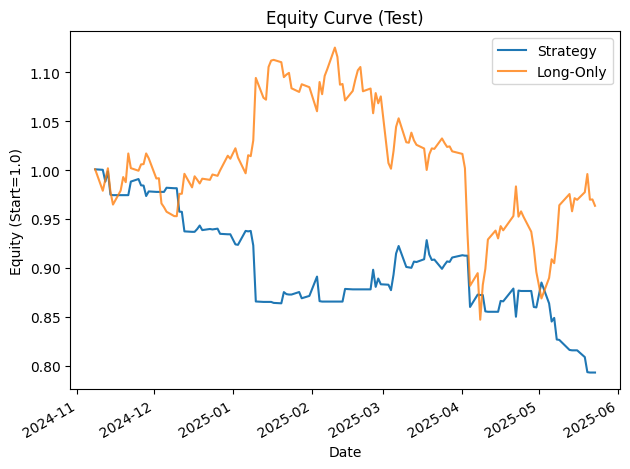

In [11]:
# === Backtest from model probabilities (daily, next-day execution) ===
import numpy as np
import pandas as pd

# 1) Get probabilities on each split (re-uses your fitted logit_clf)
yprob = {
    "train": pd.Series(logit_clf.predict_proba(X_train)[:, 1], index=X_train.index, name="p_up"),
    "val":   pd.Series(logit_clf.predict_proba(X_val)[:, 1],   index=X_val.index,   name="p_up"),
    "test":  pd.Series(logit_clf.predict_proba(X_test)[:, 1],  index=X_test.index,  name="p_up"),
}

# 2) Next-day asset returns aligned to the feature day t  → use shift(-1) of ret_1d
#    (feature @ t -> position set for t+1 -> realize return ret_1d at t+1)
asset_ret_next = mops_daily["ret_1d"].shift(-1)

def backtest_from_probs(
    probs: pd.Series,
    asset_next_ret: pd.Series,
    long_th: float = 0.55,
    short_th: float = 0.45,
    cost_bps: float = 5.0,      # round-trip cost model per unit turnover (e.g., 5 bps)
    target_vol: float | None = None,  # e.g., 0.10 for 10% annualized; None = no vol targeting
    vol_lookback: int = 20,     # rolling window for realized vol
    max_leverage: float = 3.0   # cap leverage if using vol targeting
):
    # Signals: +1 / 0 / -1 based on calibrated thresholds
    sig = np.where(probs > long_th, 1, np.where(probs < short_th, -1, 0))
    sig = pd.Series(sig, index=probs.index, name="signal").astype(int)

    # Align next-day returns to signal dates; drop last day if NaN due to shift
    ret = asset_next_ret.reindex(sig.index)
    valid = ret.notna()
    sig = sig[valid]
    ret = ret[valid]

    # Optional volatility targeting (scale position to target annualized vol)
    # Convert annual vol target -> daily target (sqrt(252) convention)
    if target_vol is not None:
        # Pre-leverage gross daily returns (unit exposure)
        gross_ret_unit = sig * ret
        # Realized daily vol (rolling)
        rolling_vol = gross_ret_unit.rolling(vol_lookback).std()
        # Scale so that realized annualized vol ~ target_vol
        # daily_target = target_vol / sqrt(252)
        daily_target = target_vol / np.sqrt(252.0)
        with np.errstate(divide="ignore", invalid="ignore"):
            lev = (daily_target / rolling_vol).clip(upper=max_leverage)
        # No leverage before we have a vol estimate
        lev = lev.fillna(0.0)
    else:
        lev = pd.Series(1.0, index=sig.index, name="leverage")

    # Transaction costs: turnover * cost_per_unit
    # Here, turnover = |pos_t - pos_{t-1}|; cost modeled in decimal (bps/1e4)
    pos = (sig * lev).rename("position")
    turnover = (pos.diff().abs()).fillna(pos.abs())  # cost for initial entry too
    cost_rate = cost_bps / 1e4
    costs = turnover * cost_rate

    # Strategy returns (net of costs)
    gross = pos * ret
    net = gross - costs

    # Equity curve and metrics
    equity = (1.0 + net).cumprod()
    n_days = net.shape[0]
    ann_factor = np.sqrt(252.0)

    total_return = equity.iloc[-1] - 1.0
    cagr = equity.iloc[-1] ** (252.0 / n_days) - 1.0 if n_days > 0 else np.nan
    sharpe = (net.mean() / net.std() * ann_factor) if net.std() > 0 else np.nan
    dd = (equity / equity.cummax()) - 1.0
    max_dd = dd.min() if len(dd) else np.nan
    hit_rate = (net > 0).mean()

    summary = {
        "days": n_days,
        "trades": int((turnover > 0).sum()),
        "turnover_sum": float(turnover.sum()),
        "total_return": float(total_return),
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(max_dd),
        "HitRate": float(hit_rate),
        "cost_bps": float(cost_bps),
        "long_th": float(long_th),
        "short_th": float(short_th),
        "target_vol": float(target_vol) if target_vol is not None else None,
    }

    out = pd.DataFrame({
        "ret": ret,
        "signal": sig,
        "leverage": lev,
        "position": pos,
        "gross_ret": gross,
        "costs": costs,
        "net_ret": net,
        "equity": equity,
    })

    return summary, out

# 3) Run the backtest on TEST (out-of-sample)
bt_params = dict(long_th=0.55, short_th=0.45, cost_bps=5.0, target_vol=None)  # start simple
test_summary, test_daily = backtest_from_probs(
    yprob["test"], asset_ret_next, **bt_params
)

print("=== Strategy Performance (TEST) ===")
for k, v in test_summary.items():
    if isinstance(v, float):
        if k in ("CAGR", "total_return", "MaxDD", "HitRate"):
            print(f"{k}: {v:.2%}")
        elif k == "Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# 4) Benchmark comparators (TEST)
# Long-only (unit exposure), with same cost model (enter on first day only)
bench_sig = pd.Series(1, index=yprob["test"].index, name="signal")
bench_ret = asset_ret_next.reindex(bench_sig.index)
bench_valid = bench_ret.notna()
bench_sig = bench_sig[bench_valid]
bench_ret = bench_ret[bench_valid]

bench_turnover = (bench_sig.diff().abs()).fillna(bench_sig.abs())
bench_costs = bench_turnover * (bt_params["cost_bps"] / 1e4)
bench_net = bench_sig * bench_ret - bench_costs
bench_eq = (1 + bench_net).cumprod()

bench_cagr = bench_eq.iloc[-1] ** (252.0 / bench_net.shape[0]) - 1.0
bench_sharpe = bench_net.mean() / bench_net.std() * np.sqrt(252.0) if bench_net.std() > 0 else np.nan
bench_maxdd = ((bench_eq / bench_eq.cummax()) - 1.0).min()

print("\n=== Long-Only Benchmark (TEST) ===")
print(f"CAGR: {bench_cagr:.2%}")
print(f"Sharpe: {bench_sharpe:.2f}")
print(f"MaxDD: {bench_maxdd:.2%}")

# 5) (Optional) Quick plot of equity curves
import matplotlib.pyplot as plt

plt.figure()
test_daily["equity"].plot(label="Strategy")
bench_eq.plot(label="Long-Only", alpha=0.8)
plt.title("Equity Curve (Test)")
plt.xlabel("Date")
plt.ylabel("Equity (Start=1.0)")
plt.legend()
plt.tight_layout()
plt.show()


=== Baseline Strategy (TEST) ===
days: 133
trades: 54
turnover_sum: 56.0000
total_return: -20.71%
CAGR: -35.58%
Sharpe: -2.05
MaxDD: -20.77%
HitRate: 27.07%
cost_bps: 5.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

=== Contrarian Strategy (TEST) ===
days: 133
trades: 54
turnover_sum: 56.0000
total_return: 16.64%
CAGR: 33.87%
Sharpe: 1.53
MaxDD: -8.69%
HitRate: 27.07%
cost_bps: 5.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None


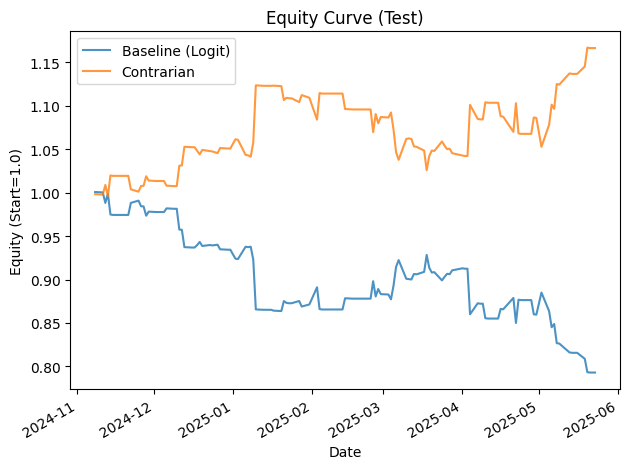

In [12]:
# === Contrarian Backtest (TEST) ===

# Run backtest as before
base_summary, base_daily = backtest_from_probs(
    yprob["test"], asset_ret_next, **bt_params
)

# Flip the signals (contrarian strategy)
contrarian_probs = 1 - yprob["test"]  # flipping probs = flipping signal logic
contra_summary, contra_daily = backtest_from_probs(
    contrarian_probs, asset_ret_next, **bt_params
)

print("=== Baseline Strategy (TEST) ===")
for k, v in base_summary.items():
    if isinstance(v, float):
        if k in ("CAGR", "total_return", "MaxDD", "HitRate"):
            print(f"{k}: {v:.2%}")
        elif k == "Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\n=== Contrarian Strategy (TEST) ===")
for k, v in contra_summary.items():
    if isinstance(v, float):
        if k in ("CAGR", "total_return", "MaxDD", "HitRate"):
            print(f"{k}: {v:.2%}")
        elif k == "Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# Plot equity curves
import matplotlib.pyplot as plt

plt.figure()
base_daily["equity"].plot(label="Baseline (Logit)", alpha=0.8)
contra_daily["equity"].plot(label="Contrarian", alpha=0.8)
plt.title("Equity Curve (Test)")
plt.xlabel("Date")
plt.ylabel("Equity (Start=1.0)")
plt.legend()
plt.tight_layout()
plt.show()


=== Top 15 Logistic Regression Coefficients ===
              feature      coef  abs_coef
7     volume_min_mean  0.466747  0.466747
12     volume_max_sum -0.431846  0.431846
8      volume_min_sum -0.374553  0.374553
10   volume_min_count  0.322999  0.322999
14   volume_max_count  0.322999  0.322999
20   n_unique_parties  0.238854  0.238854
11    volume_max_mean -0.199046  0.199046
22             ret_1d -0.132409  0.132409
15  heards_price_mean -0.104205  0.104205
3               Raise  0.101555  0.101555
4     net_raise_lower  0.097244  0.097244
21       Close_filled -0.092950  0.092950
5       net_offer_bid  0.086743  0.086743
17   heards_price_min  0.074657  0.074657
2               Offer  0.072226  0.072226


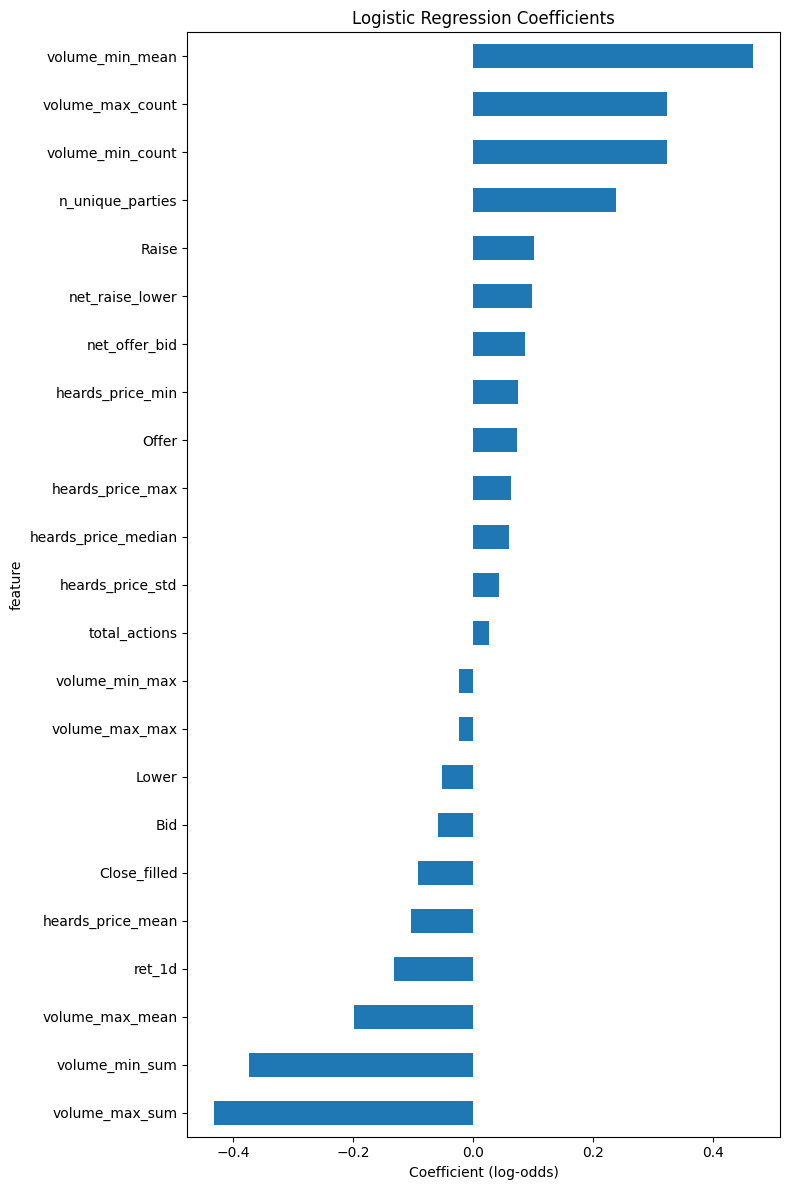

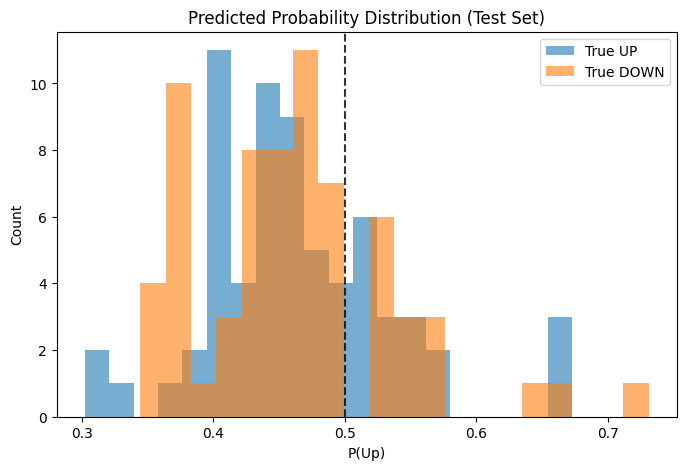


=== Example Trades (Baseline Wrong, Contrarian Profitable) ===
                 p_up  signal_baseline  signal_contra  next_ret  pnl_baseline  \
updatedDate                                                                     
2024-11-12   0.445103               -1              1  0.011622     -0.011622   
2024-11-14   0.565931                1             -1 -0.023901     -0.023901   
2024-11-26   0.407309               -1              1  0.006479     -0.006479   
2024-11-27   0.408596               -1              1  0.000291     -0.000291   
2024-11-28   0.304840               -1              1  0.010838     -0.010838   
2024-12-11   0.440556               -1              1  0.023903     -0.023903   
2024-12-12   0.397235               -1              1  0.000207     -0.000207   
2024-12-13   0.426527               -1              1  0.020875     -0.020875   
2024-12-20   0.403884               -1              1  0.004947     -0.004947   
2024-12-27   0.434065               -1       

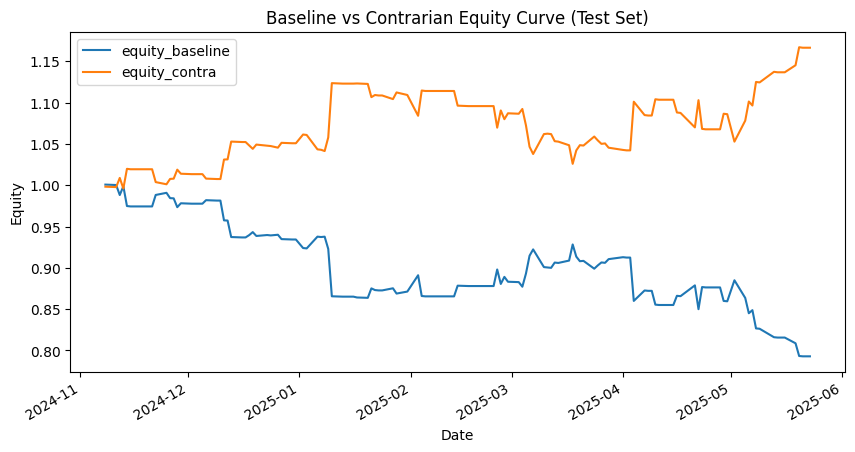

In [13]:
# === 1. MODEL DIAGNOSTICS ===

import matplotlib.pyplot as plt

# Coefficients (already computed coef_df earlier)
coef_df_full = pd.DataFrame({
    "feature": X.columns,
    "coef": logit_clf.named_steps["clf"].coef_.ravel()
})
coef_df_full["abs_coef"] = coef_df_full["coef"].abs()
coef_df_full = coef_df_full.sort_values("abs_coef", ascending=False)

print("=== Top 15 Logistic Regression Coefficients ===")
print(coef_df_full.head(15))

# Visualize coefficient distribution
plt.figure(figsize=(10,4))
coef_df_full.set_index("feature")["coef"].sort_values().plot(kind="barh", figsize=(8,12))
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

# Probability histograms: baseline vs actual label
plt.figure(figsize=(8,5))
plt.hist(yprob["test"][y_test==1], bins=20, alpha=0.6, label="True UP")
plt.hist(yprob["test"][y_test==0], bins=20, alpha=0.6, label="True DOWN")
plt.axvline(0.5, color="k", linestyle="--", alpha=0.8)
plt.title("Predicted Probability Distribution (Test Set)")
plt.xlabel("P(Up)")
plt.ylabel("Count")
plt.legend()
plt.show()


# === 2. TRADE EXAMPLES ===

# Merge predictions, signals, returns for inspection
example_df = pd.DataFrame({
    "p_up": yprob["test"],
    "signal_baseline": np.where(yprob["test"]>0.55,1,np.where(yprob["test"]<0.45,-1,0)),
    "signal_contra": np.where(yprob["test"]>0.55,-1,np.where(yprob["test"]<0.45,1,0)),
    "next_ret": asset_ret_next.reindex(yprob["test"].index),
    "realized": np.where(asset_ret_next.reindex(yprob["test"].index) > 0, 1, 0),
    "equity_baseline": base_daily["equity"],
    "equity_contra": contra_daily["equity"],
})

# Add realized PnL
example_df["pnl_baseline"] = example_df["signal_baseline"] * example_df["next_ret"]
example_df["pnl_contra"] = example_df["signal_contra"] * example_df["next_ret"]

# Show a few trades where baseline lost but contrarian won
bad_trades = example_df[(example_df["pnl_baseline"] < 0) & (example_df["pnl_contra"] > 0)]
print("\n=== Example Trades (Baseline Wrong, Contrarian Profitable) ===")
print(bad_trades.head(10)[["p_up","signal_baseline","signal_contra","next_ret","pnl_baseline","pnl_contra"]])

# Plot equity curves for context
plt.figure(figsize=(10,5))
example_df[["equity_baseline","equity_contra"]].plot(ax=plt.gca())
plt.title("Baseline vs Contrarian Equity Curve (Test Set)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.show()


=== Contrarian Model (Test Set) ===
              precision    recall  f1-score   support

           0      0.429     0.176     0.250        34
           1      0.517     0.789     0.625        38

    accuracy                          0.500        72
   macro avg      0.473     0.483     0.438        72
weighted avg      0.475     0.500     0.448        72



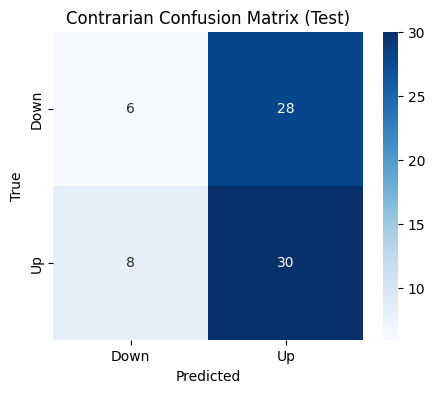

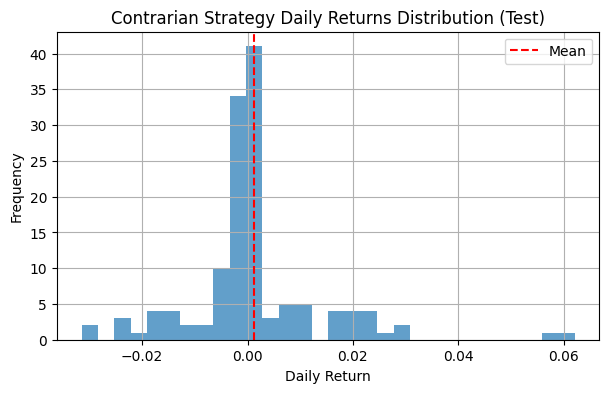

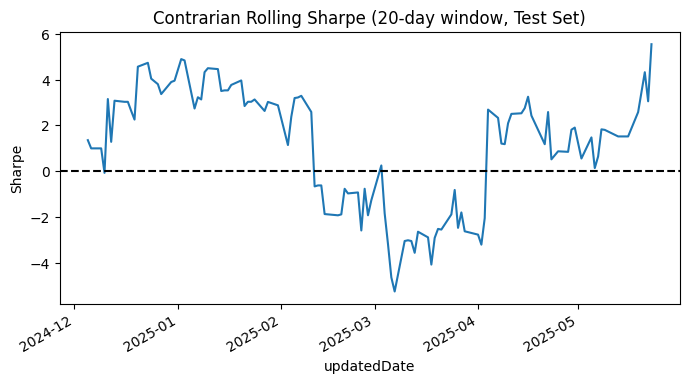

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# === CONTRARIAN LABELS ===
# Flip baseline predictions into contrarian class predictions
contra_pred = np.where(yprob["test"] > 0.55, 0, np.where(yprob["test"] < 0.45, 1, -1))
# note: -1 = flat (no trade)

# Align with true labels
y_true = y_test.loc[yprob["test"].index]

# Filter out flat (no-trade) days
mask = contra_pred != -1
contra_pred_trades = contra_pred[mask]
y_true_trades = y_true[mask]

# === Classification Metrics ===
print("=== Contrarian Model (Test Set) ===")
print(classification_report(y_true_trades, contra_pred_trades, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true_trades, contra_pred_trades)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Down","Up"], yticklabels=["Down","Up"])
plt.title("Contrarian Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# === PnL Distribution ===
plt.figure(figsize=(7,4))
contra_daily["net_ret"].hist(bins=30, alpha=0.7)
plt.axvline(contra_daily["net_ret"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Contrarian Strategy Daily Returns Distribution (Test)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# === Rolling Sharpe ===
window = 20
rolling_sharpe = contra_daily["net_ret"].rolling(window).mean() / contra_daily["net_ret"].rolling(window).std() * np.sqrt(252)
plt.figure(figsize=(8,4))
rolling_sharpe.plot()
plt.axhline(0, color="k", linestyle="--")
plt.title(f"Contrarian Rolling Sharpe ({window}-day window, Test Set)")
plt.ylabel("Sharpe")
plt.show()



=== Contrarian TRAIN Backtest ===
days: 1060
trades: 507
turnover_sum: 557.0000
total_return: -95.10%
CAGR: -51.18%
Sharpe: -1.67
MaxDD: -95.40%
HitRate: 20.47%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

=== Contrarian VAL Backtest ===
days: 132
trades: 68
turnover_sum: 72.0000
total_return: -28.90%
CAGR: -47.86%
Sharpe: -2.96
MaxDD: -33.15%
HitRate: 24.24%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

=== Contrarian TEST Backtest ===
days: 133
trades: 54
turnover_sum: 56.0000
total_return: 13.42%
CAGR: 26.95%
Sharpe: 1.27
MaxDD: -9.42%
HitRate: 26.32%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

Model saved as contrarian_baseline_model.pkl (remember: use flipped probs)

=== Contrarian Strategy (Test, $1M capital, 10bp fees) ===
days: 133
trades: 54
turnover_sum: 56.0000
total_return: 13.42%
CAGR: 26.95%
Sharpe: 1.27
MaxDD: -9.42%
HitRate: 26.32%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

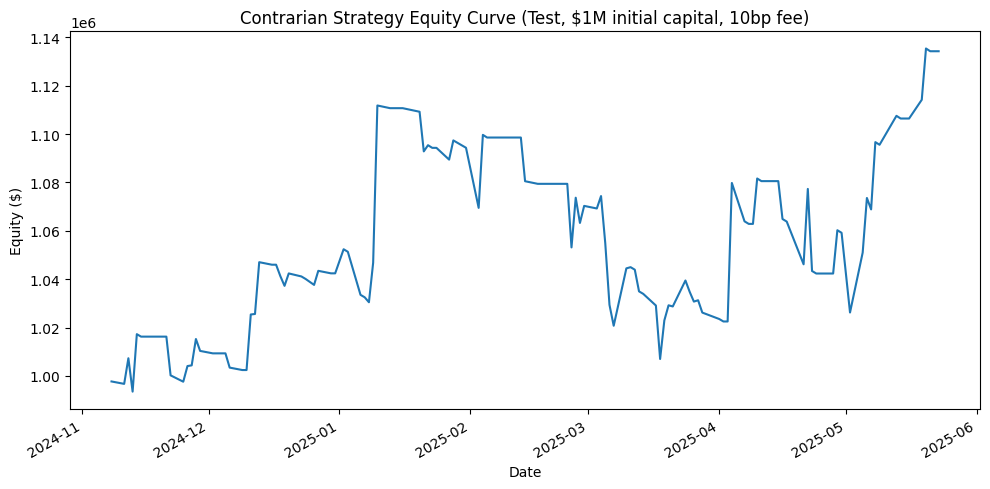

In [15]:
import joblib

# === Step 1. Check contrarian performance across splits ===
splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
for split, (X_split, y_split) in splits.items():
    probs = yprob[split]
    contra_probs = 1 - probs
    summary, _ = backtest_from_probs(contra_probs, asset_ret_next, long_th=0.55, short_th=0.45, cost_bps=10.0)
    print(f"\n=== Contrarian {split.upper()} Backtest ===")
    for k,v in summary.items():
        if isinstance(v,float):
            if k in ("CAGR","total_return","MaxDD","HitRate"):
                print(f"{k}: {v:.2%}")
            elif k=="Sharpe":
                print(f"{k}: {v:.2f}")
            else:
                print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

# === Step 2. Save logistic regression (contrarian baseline) ===
joblib.dump(logit_clf, "contrarian_baseline_model.pkl")
print("\nModel saved as contrarian_baseline_model.pkl (remember: use flipped probs)")

# === Step 3. Backtest on TEST with $1M initial capital & 10bp costs ===
start_capital = 1_000_000
contra_probs_test = 1 - yprob["test"]
test_summary, test_daily = backtest_from_probs(
    contra_probs_test, asset_ret_next, long_th=0.55, short_th=0.45, cost_bps=10.0
)

# Scale equity curve to $1m
test_daily["equity_$"] = start_capital * test_daily["equity"]

print("\n=== Contrarian Strategy (Test, $1M capital, 10bp fees) ===")
for k,v in test_summary.items():
    if isinstance(v,float):
        if k in ("CAGR","total_return","MaxDD","HitRate"):
            print(f"{k}: {v:.2%}")
        elif k=="Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# Plot dollar equity curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
test_daily["equity_$"].plot()
plt.title("Contrarian Strategy Equity Curve (Test, $1M initial capital, 10bp fee)")
plt.ylabel("Equity ($)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


In [16]:
import matplotlib.pyplot as plt
import joblib
import os
import zipfile
from google.colab import files

# === 1. Save your model ===
joblib.dump(logit_clf, "contrarian_baseline_model.pkl")

# === 2. Re-generate and save key plots as PNGs ===

# Equity curve (Baseline vs Contrarian)
plt.figure(figsize=(10,5))
base_daily["equity"].plot(label="Baseline", alpha=0.8)
contra_daily["equity"].plot(label="Contrarian", alpha=0.8)
plt.title("Baseline vs Contrarian Equity Curve (Test Set)")
plt.xlabel("Date")
plt.ylabel("Equity (Start=1.0)")
plt.legend()
plt.tight_layout()
plt.savefig("equity_baseline_vs_contra.png")
plt.close()

# Predicted probability distribution
plt.figure(figsize=(8,5))
plt.hist(yprob["test"][y_test==1], bins=20, alpha=0.6, label="True UP")
plt.hist(yprob["test"][y_test==0], bins=20, alpha=0.6, label="True DOWN")
plt.axvline(0.5, color="k", linestyle="--")
plt.title("Predicted Probability Distribution (Test Set)")
plt.xlabel("P(Up)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("prob_distribution.png")
plt.close()

# Logistic regression coefficients
coef_df_full.set_index("feature")["coef"].sort_values().plot(kind="barh", figsize=(8,12))
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.savefig("logistic_coefficients.png")
plt.close()

# Contrarian equity curve ($1M)
plt.figure(figsize=(10,5))
test_daily["equity_$"].plot()
plt.title("Contrarian Strategy Equity Curve (Test, $1M, 10bp fee)")
plt.ylabel("Equity ($)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("equity_contra_$1m.png")
plt.close()

# Daily return distribution (contrarian)
contra_daily["net_ret"].hist(bins=30, alpha=0.7)
plt.axvline(contra_daily["net_ret"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Contrarian Strategy Daily Returns Distribution (Test)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("contrarian_ret_distribution.png")
plt.close()

# Rolling Sharpe (contrarian)
rolling_sharpe = contra_daily["net_ret"].rolling(20).mean() / contra_daily["net_ret"].rolling(20).std() * (252**0.5)
rolling_sharpe.plot()
plt.axhline(0, color="k", linestyle="--")
plt.title("Contrarian Rolling Sharpe (20-day window, Test)")
plt.ylabel("Sharpe")
plt.tight_layout()
plt.savefig("contrarian_rolling_sharpe.png")
plt.close()

# === 3. Zip everything together ===
with zipfile.ZipFile("contrarian_model_and_plots.zip", "w") as zf:
    zf.write("contrarian_baseline_model.pkl")
    zf.write("equity_baseline_vs_contra.png")
    zf.write("prob_distribution.png")
    zf.write("logistic_coefficients.png")
    zf.write("equity_contra_$1m.png")
    zf.write("contrarian_ret_distribution.png")
    zf.write("contrarian_rolling_sharpe.png")

# === 4. Download the zip ===
files.download("contrarian_model_and_plots.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>